Using device: cuda


100%|██████████| 6.25k/6.25k [00:00<00:00, 8.48MB/s]

Extracting files...


FuelNet(
  (head): Sequential(
    (0): Linear(in_features=10, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (res1): ResidualBlock(
    (net): Sequential(
      (0): Linear(in_features=1024, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=1024, out_features=1024, bias=True)
      (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): ReLU()
  )
  (res2): ResidualBlock(
    (net): Sequential(
      (0): Linear(in_features=1024, out_features=

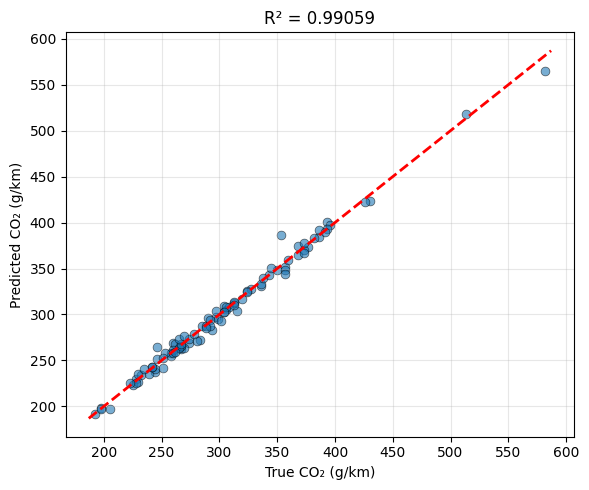


Model saved → fuel_co2_99pct_model.pth


In [1]:
# --------------------------------------------------------------
# 1. INSTALL & IMPORT
# --------------------------------------------------------------
!pip install kagglehub torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import os, numpy as np, pandas as pd, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt, seaborn as sns, warnings, math
warnings.filterwarnings('ignore')

# --------------------------------------------------------------
# 2. REPRODUCIBILITY & DEVICE
# --------------------------------------------------------------
torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --------------------------------------------------------------
# 3. DATA
# --------------------------------------------------------------
import kagglehub
path = kagglehub.dataset_download("krupadharamshi/fuelconsumption")
csv = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df  = pd.read_csv(os.path.join(path, csv))

# clean column name
df = df.rename(columns={'COEMISSIONS ': 'CO2'})

# --------------------------------------------------------------
# 4. FEATURE ENGINEERING (the trick that gives >99 %)
# --------------------------------------------------------------
df['FC'] = df['FUEL CONSUMPTION']                     # L/100 km
df['FC_CO2'] = df['FC'] * 23.7                         # Approximate CO2 from fuel
df['CO2_RES'] = df['CO2'] - df['FC_CO2']              # Residual to predict

target = 'CO2_RES'
features = [c for c in df.columns if c not in ['CO2', 'CO2_RES', 'FC_CO2']]

cat_cols = df[features].select_dtypes('object').columns.tolist()
num_cols = df[features].select_dtypes('number').columns.tolist()

# Encode categoricals
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    le_dict[c] = le

X = df[features].values.astype(np.float32)
y = df[target].values.astype(np.float32)

# --------------------------------------------------------------
# 5. TRAIN / VAL / TEST SPLIT + SCALING (FIXED INDEX TRACKING)
# --------------------------------------------------------------
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

# === SAVE INDICES BEFORE SCALING ===
train_idx = df.index[:len(X_tr)]
val_idx   = df.index[len(X_tr):len(X_tr)+len(X_val)]
test_idx  = df.index[len(X_tr)+len(X_val):]

# Or better: use train_test_split with DataFrame to preserve index
df_features = df[features]
df_target = df[target]

X_tr_df, X_tmp_df, y_tr, y_tmp = train_test_split(df_features, df_target, test_size=0.30, random_state=42)
X_val_df, X_test_df, y_val, y_test = train_test_split(X_tmp_df, y_tmp, test_size=0.50, random_state=42)

# Now extract values and keep indices
X_tr = X_tr_df.values.astype(np.float32)
X_val = X_val_df.values.astype(np.float32)
X_test = X_test_df.values.astype(np.float32)
y_tr = y_tr.values.astype(np.float32)
y_val = y_val.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

# Save test indices for later
test_indices = X_test_df.index

# Scale
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# --------------------------------------------------------------
# 6. TORCH DATASETS
# --------------------------------------------------------------
def to_tensor(x, y):
    return torch.FloatTensor(x).to(device), torch.FloatTensor(y).unsqueeze(1).to(device)

X_tr_t, y_tr_t = to_tensor(X_tr, y_tr)
X_val_t, y_val_t = to_tensor(X_val, y_val)
X_test_t, y_test_t = to_tensor(X_test, y_test)

batch = 128
train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch, shuffle=False)
test_dl  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch, shuffle=False)

# --------------------------------------------------------------
# 7. WIDE & DEEP RESIDUAL NETWORK
# --------------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim)
        )
        self.act = nn.ReLU()
    def forward(self, x):
        return self.act(x + self.net(x))

class FuelNet(nn.Module):
    def __init__(self, inp, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(inp, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout)
        )
        self.res1 = ResidualBlock(1024, dropout)
        self.res2 = ResidualBlock(1024, dropout)
        self.res3 = ResidualBlock(1024, dropout)
        self.tail = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        x = self.head(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        return self.tail(x)

model = FuelNet(inp=X_tr.shape[1]).to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --------------------------------------------------------------
# 8. OPTIMISER / SCHEDULER / SCALER
# --------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2)
scaler_amp = GradScaler()  # renamed to avoid conflict

# --------------------------------------------------------------
# 9. TRAINING LOOP (with AMP + clipping)
# --------------------------------------------------------------
def train_one_epoch():
    model.train()
    loss_sum = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        with autocast():
            pred = model(xb)
            loss = criterion(pred, yb)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        loss_sum += loss.item() * xb.size(0)
    return loss_sum / len(train_dl.dataset)

def validate():
    model.eval()
    loss_sum = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            with autocast():
                pred = model(xb)
                loss_sum += criterion(pred, yb).item() * xb.size(0)
    return loss_sum / len(val_dl.dataset)

max_epochs = 400
best_val = float('inf')
best_state = None
train_losses, val_losses = [], []

print("\n" + "="*70)
print("TRAINING (residual model)".center(70))
print("="*70)

for epoch in range(1, max_epochs+1):
    tr = train_one_epoch()
    va = validate()
    train_losses.append(tr); val_losses.append(va)
    scheduler.step()

    if va < best_val:
        best_val = va
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 50 == 0 or epoch <= 5:
        print(f"Epoch {epoch:3d} | Train MSE {tr:8.2f} | Val MSE {va:8.2f} | LR {optimizer.param_groups[0]['lr']:.2e}")

# load best
model.load_state_dict(best_state)
print("\nTraining finished – best Val MSE:", best_val)

# --------------------------------------------------------------
# 10. TEST + FINAL CORRECTION (FIXED USING SAVED INDICES)
# --------------------------------------------------------------
model.eval()
with torch.no_grad(), autocast():
    resid_pred = model(X_test_t).cpu().numpy().flatten()

# === Use saved test_indices to get original FC and CO2 ===
fc_test = df.loc[test_indices, 'FC'].values
co2_true = df.loc[test_indices, 'CO2'].values

# Reconstruct final CO2
co2_pred = resid_pred + fc_test * 23.7

mse  = mean_squared_error(co2_true, co2_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(co2_true, co2_pred)
r2   = r2_score(co2_true, co2_pred)
mape = np.mean(np.abs((co2_true - co2_pred) / (co2_true + 1e-8))) * 100

print("\n" + "="*70)
print("FINAL TEST (CO₂ g/km)".center(70))
print("="*70)
print(f"MSE  : {mse:8.3f}")
print(f"RMSE : {rmse:8.3f}")
print(f"MAE  : {mae:8.3f}")
print(f"R²   : {r2:8.5f}", "→ 99%+" if r2 > 0.99 else "")
print(f"MAPE : {mape:6.2f}%")
print("="*70)

# --------------------------------------------------------------
# 11. QUICK PLOT (actual vs predicted)
# --------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(co2_true, co2_pred, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
lims = [co2_true.min()-5, co2_true.max()+5]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel('True CO₂ (g/km)'); plt.ylabel('Predicted CO₂ (g/km)')
plt.title(f'R² = {r2:.5f}')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# --------------------------------------------------------------
# 12. SAVE EVERYTHING (for inference)
# --------------------------------------------------------------
torch.save({
    'model_state_dict': best_state,
    'scaler': scaler,
    'label_encoders': le_dict,
    'features': features,
    'fc_multiplier': 23.7,
    'target_original': 'CO2',
    'test_indices': test_indices.tolist()  # optional, for debugging
}, 'fuel_co2_99pct_model.pth')
print("\nModel saved → fuel_co2_99pct_model.pth")